# 🎯 Project Objective
Develop a quantitative model to explain and predict IBM option price movements using Greeks via linear modeling, and backtest one or more investment strategies based on those predictions.

## 🧱 Project Structure

### 1 - Data Preparation & Feature Engineering

### 2 - Option Return Modeling Using Greeks

### 3 - Backtesting Prediction-Based Trading Strategies

### 1 - Data Preparation & Feature Engineering

Récupération des données d'Nvidia depuis la date du 2017-11-15.

In [30]:
import numpy as np
import yfinance as yf
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import KFold, cross_validate, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from scipy.stats import norm
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras import layers, models

In [4]:
# Définir le symbole boursier et la période
symbol = "NVDA"
start_date = "2017-11-15"
end_date = "2025-04-09"  # Remplacez par la date actuelle ou la date souhaitée

# Télécharger les données
NVDA_data = yf.download(symbol, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [5]:
NVDA_data.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2017-11-15,5.188677,5.238593,5.134809,5.237357,501948000
2017-11-16,5.228954,5.292954,5.220058,5.262807,441768000
2017-11-17,5.222777,5.321371,5.207704,5.286035,515664000
2017-11-20,5.289989,5.302097,5.201526,5.238344,396100000
2017-11-21,5.338669,5.350283,5.297897,5.329773,399176000


In [6]:
NVDA_data.columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

In [7]:
# Calcul des rendements (logarithmiques ou simples)
NVDA_data['Returns'] = NVDA_data['Close'].pct_change()

# Afficher les résultats
NVDA_data.head()

Price,Close,High,Low,Open,Volume,Returns
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,
Date,,,,,,
2017-11-15,5.188677,5.238593,5.134809,5.237357,501948000,NaN
2017-11-16,5.228954,5.292954,5.220058,5.262807,441768000,0.007762
2017-11-17,5.222777,5.321371,5.207704,5.286035,515664000,-0.001181
2017-11-20,5.289989,5.302097,5.201526,5.238344,396100000,0.012869
2017-11-21,5.338669,5.350283,5.297897,5.329773,399176000,0.009202


In [8]:
# Supprimer les lignes avec des NaN dans 'Returns' avant de calculer la volatilité
NVDA_data = NVDA_data.dropna(subset=[('Returns',     '')])

# Calculer la volatilité avec une fenêtre de 5 jours
NVDA_data['Volatility_Historical'] = NVDA_data['Returns'].rolling(window=30).std()

# Afficher les résultats
print(NVDA_data[['Returns', 'Volatility_Historical']].head())


Price        Returns Volatility_Historical
Ticker                                    
Date                                      
2017-11-16  0.007762                   NaN
2017-11-17 -0.001181                   NaN
2017-11-20  0.012869                   NaN
2017-11-21  0.009202                   NaN
2017-11-22 -0.004493                   NaN


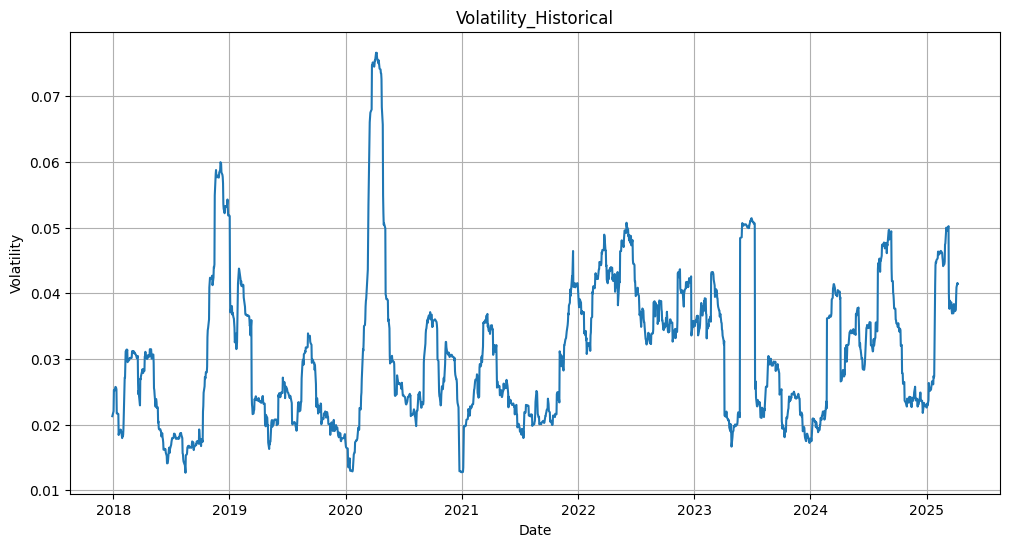

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(NVDA_data['Volatility_Historical'])
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title("Volatility_Historical")
plt.grid()

plt.show()

In [10]:
# Fonction pour calculer les Grecs via Black-Scholes
def black_scholes_greeks(S, K, T, r, sigma ):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if K > S : 
        option_type='call'
    else : 
        option_type='put'
    
    if option_type == 'call':
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
        vega = S * np.sqrt(T) * norm.pdf(d1)
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    else:  # Put option
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
        vega = S * np.sqrt(T) * norm.pdf(d1)
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)
    
    # Retourner les résultats sous forme de valeurs simples
    return delta.item(), gamma.item(), theta.item(), vega.item(), rho.item()


On définit K comme la moyenne des 30 derniers jours pour avoir un prix d'exercice realiste +10%

In [11]:
NVDA_data['K'] = NVDA_data['Close'].rolling(window=50).mean()*1.1

# Réinitialiser les colonnes du DataFrame en supprimant 'NVDA'
NVDA_data.columns = NVDA_data.columns.droplevel(1)

In [12]:
NVDA_data = NVDA_data.dropna()
NVDA_data.head()

Price,Close,High,Low,Open,Volume,Returns,Volatility_Historical,K
Date,,,,,,,,
2018-01-30,6.001860,6.093352,5.895285,5.962049,570832000,-0.016731,0.018526,5.712547
2018-01-31,6.078020,6.163825,6.044638,6.077278,478576000,0.012689,0.018217,5.731227
2018-02-01,5.946965,6.105222,5.886630,5.898005,519224000,-0.021562,0.018405,5.747159
2018-02-02,5.774366,5.884404,5.716257,5.860418,718464000,-0.029023,0.019332,5.757815
2018-02-05,5.284268,5.767196,5.069138,5.613144,1165204000,-0.084875,0.025483,5.756618


In [13]:
# Supposons des valeurs par défaut pour T (temps à expiration) et r (taux sans risque)
T = 30 / 365  # Temps à expiration (par exemple, 30 jours)
r = 0.05  # Taux sans risque (par exemple, 1%)

def apply_greeks(row):
    S = row['Close']
    K = row['K']  # Utilise le K dynamique du DataFrame
    T = 1.0  # 1 an pour des résultats stables
    r = 0.01  # Taux sans risque
    sigma = row['Volatility_Historical']
    
    greeks = black_scholes_greeks(S, K, T, r, sigma)
    return pd.Series(greeks, index=['delta', 'gamma', 'theta', 'vega', 'rho'])


In [18]:
# Appliquer la fonction pour obtenir les Grecs 
NVDA_data[['delta', 'gamma', 'theta', 'vega', 'rho']] = NVDA_data.apply(apply_greeks, axis=1)

# Afficher les résultats
print(NVDA_data[['Close', 'Volatility_Historical', 'delta', 'gamma', 'theta', 'vega', 'rho']].head())

Price          Close  Volatility_Historical     delta     gamma     theta  \
Date                                                                        
2018-01-30  6.001860               0.018526 -0.000650  0.020379 -0.000087   
2018-01-31  6.078020               0.018217 -0.000077  0.002813 -0.000013   
2018-02-01  5.946965               0.018405 -0.007990  0.200045 -0.000720   
2018-02-02  5.774366               0.019332 -0.249701  2.844904 -0.003139   
2018-02-05  5.284268               0.025483  0.001566  0.037678 -0.000424   

Price           vega       rho  
Date                            
2018-01-30  0.013600 -0.003923  
2018-01-31  0.001893 -0.000473  
2018-02-01  0.130214 -0.047809  
2018-02-02  1.833794 -1.458653  
2018-02-05  0.026811  0.008213  


In [19]:
NVDA_data.head()

Price,Close,High,Low,Open,Volume,Returns,Volatility_Historical,K,delta,gamma,theta,vega,rho
Date,,,,,,,,,,,,,
2018-01-30,6.001860,6.093352,5.895285,5.962049,570832000,-0.016731,0.018526,5.712547,-0.000650,0.020379,-0.000087,0.013600,-0.003923
2018-01-31,6.078020,6.163825,6.044638,6.077278,478576000,0.012689,0.018217,5.731227,-0.000077,0.002813,-0.000013,0.001893,-0.000473
2018-02-01,5.946965,6.105222,5.886630,5.898005,519224000,-0.021562,0.018405,5.747159,-0.007990,0.200045,-0.000720,0.130214,-0.047809
2018-02-02,5.774366,5.884404,5.716257,5.860418,718464000,-0.029023,0.019332,5.757815,-0.249701,2.844904,-0.003139,1.833794,-1.458653
2018-02-05,5.284268,5.767196,5.069138,5.613144,1165204000,-0.084875,0.025483,5.756618,0.001566,0.037678,-0.000424,0.026811,0.008213


In [20]:
NVDA_data['target'] = (NVDA_data['Close'].shift(-1) > NVDA_data['Close']).astype(int)
NVDA_data = NVDA_data.dropna()  # pour virer la dernière ligne avec target=NaN
data = NVDA_data

In [21]:
# Sélectionner uniquement les colonnes des Greeks
greeks_columns = ['delta', 'gamma', 'theta', 'vega', 'rho','target']
greeks_data = NVDA_data[greeks_columns]

# 2 - Creation of machine learning models

In [25]:
# Création des séquences
sequence_length = 6
result = []
for index in range(len(data) - sequence_length):
    result.append(greeks_data[index: index + sequence_length])
result = np.array(result)

# Découpage train/test
row = round(0.8 * result.shape[0])
train = result[:int(row)]
test = result[int(row):]

# Indice de la colonne "target"
target_index = greeks_data.columns.get_loc("target")

# Construction des X et y
x_train = train[:, :-1]         # shape: [n_samples, 5, n_features]
x_test = test[:, :-1]

# Flatten pour Random Forest: on passe de [5, n_features] → [5 * n_features]
x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))

y_train = train[:, -1, target_index]
y_test = test[:, -1, target_index]

# Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Résultats
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[ 89  72]
 [107  92]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.45      0.55      0.50       161
         1.0       0.56      0.46      0.51       199

    accuracy                           0.50       360
   macro avg       0.51      0.51      0.50       360
weighted avg       0.51      0.50      0.50       360



In [28]:
# Normalisation
scaler = MinMaxScaler()
data = scaler.fit_transform(NVDA_data)

# Création des séquences
sequence_length = 6
result = []
for index in range(len(data) - sequence_length):
    result.append(data[index: index + sequence_length])
result = np.array(result)

# Découpage train/test
row = round(0.8 * result.shape[0])
train = result[:int(row)]
test = result[int(row):]

# Indice de la colonne "target"
target_index = NVDA_data.columns.get_loc("target")

# Construction des X et y
x_train = train[:, :-1]         # shape: [n_samples, 5, n_features]
x_test = test[:, :-1]

# Flatten pour Random Forest: on passe de [5, n_features] → [5 * n_features]
x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))

y_train = train[:, -1, target_index]
y_test = test[:, -1, target_index]

# Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Résultats
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[100  61]
 [137  62]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.42      0.62      0.50       161
         1.0       0.50      0.31      0.39       199

    accuracy                           0.45       360
   macro avg       0.46      0.47      0.44       360
weighted avg       0.47      0.45      0.44       360



Confusion Matrix:
 [[ 77  85]
 [ 90 110]]

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.48      0.47       162
           1       0.56      0.55      0.56       200

    accuracy                           0.52       362
   macro avg       0.51      0.51      0.51       362
weighted avg       0.52      0.52      0.52       362



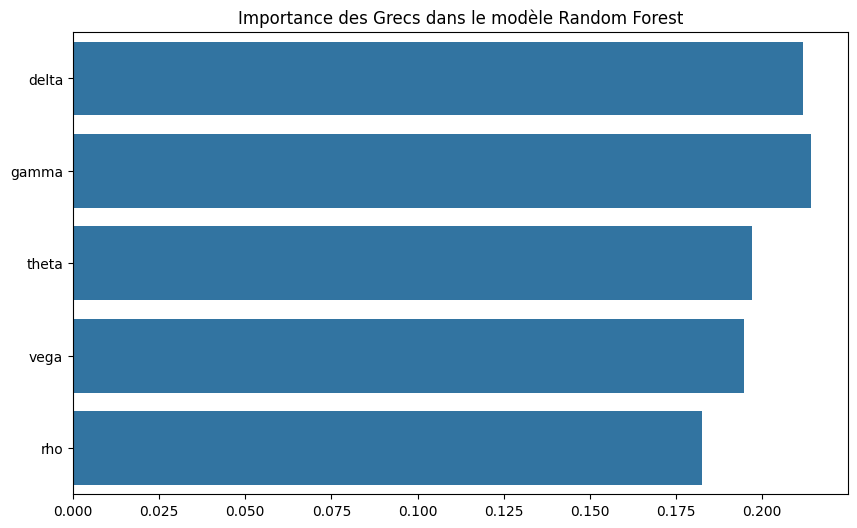

In [31]:
# Sélectionner uniquement les Grecs comme features
greek_columns = ['delta', 'gamma', 'theta', 'vega', 'rho']
NVDA_data_greeks = NVDA_data[greek_columns]

# Normalisation des Grecs
scaler = MinMaxScaler()
data = scaler.fit_transform(NVDA_data_greeks)

# Créer le target (1 = hausse, 0 = baisse du prix le lendemain)
y = (NVDA_data['target'] > 0).astype(int)  # 1 pour hausse, 0 pour baisse

# Diviser les données en train/test
train_size = int(0.8 * len(data))
x_train = data[:train_size]
x_test = data[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# Initialisation et entraînement du modèle Random Forest
clf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',  # Pour gérer le déséquilibre des classes
    random_state=42
)

clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Résultats de la prédiction
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualisation de l'importance des Grecs dans le modèle
importances = clf.feature_importances_
feature_names = greek_columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Importance des Grecs dans le modèle Random Forest")
plt.show()

In [32]:
clf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,
    min_samples_split=4,
    class_weight='balanced',
    random_state=42
)

Confusion Matrix:
 [[ 94  68]
 [107  93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.58      0.52       162
           1       0.58      0.47      0.52       200

    accuracy                           0.52       362
   macro avg       0.52      0.52      0.52       362
weighted avg       0.53      0.52      0.52       362



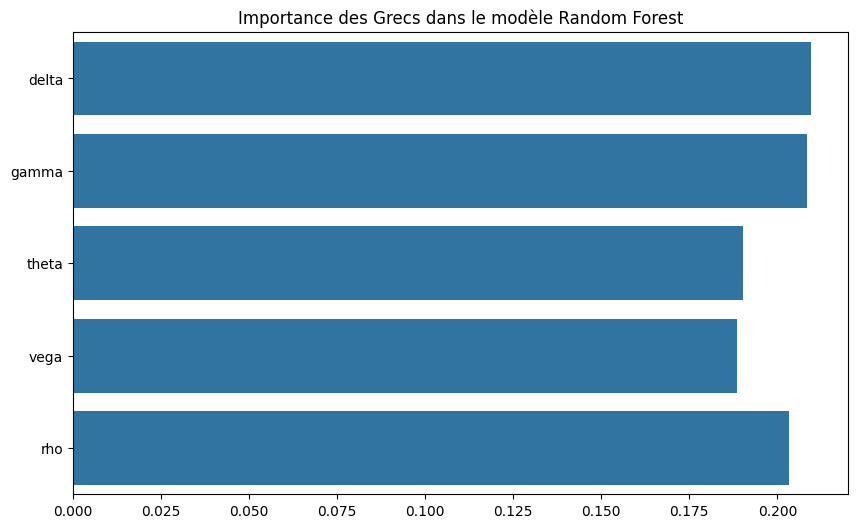

In [33]:
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Résultats de la prédiction
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualisation de l'importance des Grecs dans le modèle
importances = clf.feature_importances_
feature_names = greek_columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Importance des Grecs dans le modèle Random Forest")
plt.show()

In [34]:
clf = RandomForestClassifier(
    n_estimators=300,  # Plus d'arbres pour mieux capturer la structure des données
    max_depth=15,  # Limite de profondeur pour éviter le surapprentissage
    min_samples_split=5,  # Moins de division pour éviter l'overfitting
    class_weight='balanced',
    random_state=42
)

Confusion Matrix:
 [[ 82  80]
 [102  98]]

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.51      0.47       162
           1       0.55      0.49      0.52       200

    accuracy                           0.50       362
   macro avg       0.50      0.50      0.50       362
weighted avg       0.50      0.50      0.50       362



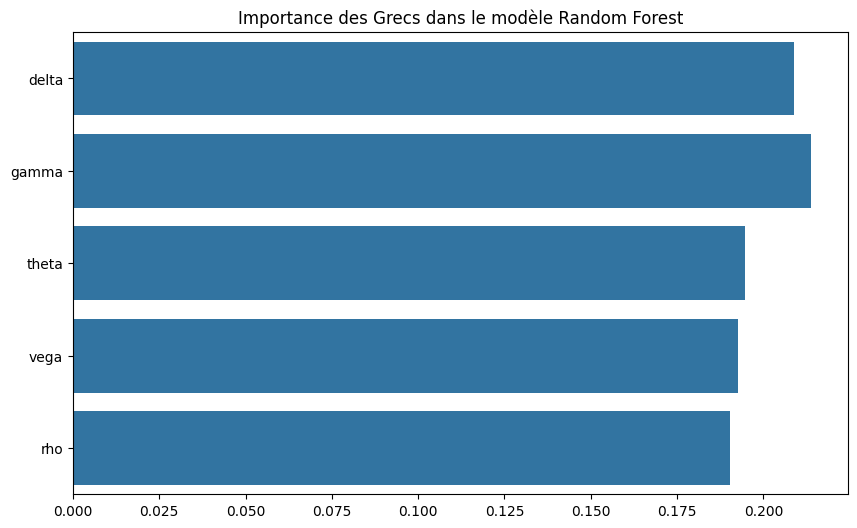

In [35]:
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Résultats de la prédiction
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualisation de l'importance des Grecs dans le modèle
importances = clf.feature_importances_
feature_names = greek_columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Importance des Grecs dans le modèle Random Forest")
plt.show()

In [36]:
clf_xgb = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=10,
    scale_pos_weight=10,  # Ajuste le poids pour les classes déséquilibrées
    random_state=42
)
clf_xgb.fit(x_train, y_train)
y_pred_xgb = clf_xgb.predict(x_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.45      0.38      0.41       162
           1       0.56      0.63      0.59       200

    accuracy                           0.52       362
   macro avg       0.50      0.50      0.50       362
weighted avg       0.51      0.52      0.51       362



In [37]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, cv=3)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


In [38]:
# Réentraîner le modèle avec les meilleurs paramètres trouvés
clf_optimized = RandomForestClassifier(
    max_depth=20,
    min_samples_split=10,
    n_estimators=100,
    class_weight='balanced',  # Rappel, ajuster le poids des classes si nécessaire
    random_state=42
)
clf_optimized.fit(x_train, y_train)

# Faire des prédictions
y_pred_optimized = clf_optimized.predict(x_test)

# Évaluer le modèle
print("Classification Report:")
print(classification_report(y_test, y_pred_optimized))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimized))

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.66      0.54       162
           1       0.56      0.35      0.44       200

    accuracy                           0.49       362
   macro avg       0.51      0.51      0.49       362
weighted avg       0.51      0.49      0.48       362

Confusion Matrix:
[[107  55]
 [129  71]]


In [39]:
# Calcul des probabilités
y_prob = clf_optimized.predict_proba(x_test)[:, 1]

# Ajuster le seuil à 0.4 par exemple
y_pred_adjusted = (y_prob > 0.4).astype(int)

# Recalculer la matrice de confusion et le classification report
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

[[ 57 105]
 [ 60 140]]
              precision    recall  f1-score   support

           0       0.49      0.35      0.41       162
           1       0.57      0.70      0.63       200

    accuracy                           0.54       362
   macro avg       0.53      0.53      0.52       362
weighted avg       0.53      0.54      0.53       362



In [40]:
auc = roc_auc_score(y_test, clf_optimized.predict_proba(x_test)[:, 1])
print("ROC-AUC:", auc)

ROC-AUC: 0.5360802469135802


In [41]:
# Initialisation du classifieur
clf = RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=100)

# Initialisation de la validation croisée avec StratifiedKFold pour garder la proportion des classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calcul de la précision à chaque itération de validation croisée
cv_scores = cross_val_score(clf, x_train, y_train, cv=cv, scoring='accuracy')

# Affichage des résultats
print(f"Validation Croisée - Scores de Précision: {cv_scores}")
print(f"Précision Moyenne: {cv_scores.mean()} (+/- {cv_scores.std()})")

Validation Croisée - Scores de Précision: [0.55862069 0.51211073 0.51557093 0.5017301  0.52249135]
Précision Moyenne: 0.5221047607684047 (+/- 0.01944870569782877)


In [42]:
# Validation croisée avec des métriques détaillées
cv_results = cross_validate(clf, x_train, y_train, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'])

# Affichage des résultats
print(f"Validation Croisée - Précision Moyenne: {cv_results['test_accuracy'].mean()}")
print(f"Validation Croisée - Précision: {cv_results['test_precision'].mean()}")
print(f"Validation Croisée - Rappel: {cv_results['test_recall'].mean()}")
print(f"Validation Croisée - F1-Score: {cv_results['test_f1'].mean()}")

# Afficher la variation des scores
print(f"Variabilité des scores (std) :")
print(f"  Précision: {cv_results['test_precision'].std()}")
print(f"  Rappel: {cv_results['test_recall'].std()}")
print(f"  F1-Score: {cv_results['test_f1'].std()}")

Validation Croisée - Précision Moyenne: 0.5158811597661377
Validation Croisée - Précision: 0.5372744532866254
Validation Croisée - Rappel: 0.6613741097612065
Validation Croisée - F1-Score: 0.5925761900802937
Variabilité des scores (std) :
  Précision: 0.02083834332150802
  Rappel: 0.04279314899829433
  F1-Score: 0.027104592803114832


In [43]:
# Initialisation du modèle XGBoost
xgb_model = xgb.XGBClassifier(max_depth=20, min_samples_split=10, n_estimators=100, objective='binary:logistic', eval_metric='logloss')

# Validation croisée avec des métriques détaillées
cv_results_xgb = cross_validate(xgb_model, x_train, y_train, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'])

# Affichage des résultats
print(f"Validation Croisée - Précision Moyenne: {cv_results_xgb['test_accuracy'].mean()}")
print(f"Validation Croisée - Précision: {cv_results_xgb['test_precision'].mean()}")
print(f"Validation Croisée - Rappel: {cv_results_xgb['test_recall'].mean()}")
print(f"Validation Croisée - F1-Score: {cv_results_xgb['test_f1'].mean()}")

# Afficher la variation des scores
print(f"Variabilité des scores (std) :")
print(f"  Précision: {cv_results_xgb['test_precision'].std()}")
print(f"  Rappel: {cv_results_xgb['test_recall'].std()}")
print(f"  F1-Score: {cv_results_xgb['test_f1'].std()}")

/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:05:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:05:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:05:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:05:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "min_samples

Validation Croisée - Précision Moyenne: 0.47026846438372505
Validation Croisée - Précision: 0.5048100443107686
Validation Croisée - Rappel: 0.49674067867616245
Validation Croisée - F1-Score: 0.4996340536966999
Variabilité des scores (std) :
  Précision: 0.01916960715373035
  Rappel: 0.03246251457906321
  F1-Score: 0.013640287779714084


In [44]:
# Créer le modèle
model = Sequential()

# Ajouter des couches Dense (couches entièrement connectées)
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu'))  # Première couche avec activation ReLU
model.add(Dropout(0.5))  # Dropout pour éviter le sur-apprentissage
model.add(Dense(32, activation='relu'))  # Deuxième couche avec activation ReLU
model.add(Dropout(0.5))  # Dropout
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Couche de sortie avec activation Sigmoid pour la classification binaire

# Compiler le modèle
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Afficher le résumé du modèle
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                384       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 128)               4224      
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 1

In [45]:
# Entraîner le modèle
history = model.fit(x_train, y_train, epochs=15, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/15


2025-04-14 22:05:10.925852: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


46/46 [==============================] - 1s 3ms/step - loss: 0.6902 - accuracy: 0.5235 - val_loss: 0.6893 - val_accuracy: 0.5525
Epoch 2/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6914 - accuracy: 0.5145 - val_loss: 0.6890 - val_accuracy: 0.5525
Epoch 3/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6923 - accuracy: 0.5214 - val_loss: 0.6918 - val_accuracy: 0.5525
Epoch 4/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6921 - accuracy: 0.5207 - val_loss: 0.6903 - val_accuracy: 0.5525
Epoch 5/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6919 - accuracy: 0.5297 - val_loss: 0.6904 - val_accuracy: 0.5525
Epoch 6/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6902 - accuracy: 0.5339 - val_loss: 0.6893 - val_accuracy: 0.5525
Epoch 7/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6921 - accuracy: 0.5221 - val_loss: 0.6891 - val_accuracy: 0.5525
Epoch 8/15
46/46 [=============

In [46]:
# Évaluation du modèle sur les données de test
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

12/12 [==============================] - 0s 616us/step - loss: 0.6899 - accuracy: 0.5525
Test Loss: 0.6898745894432068
Test Accuracy: 0.5524861812591553


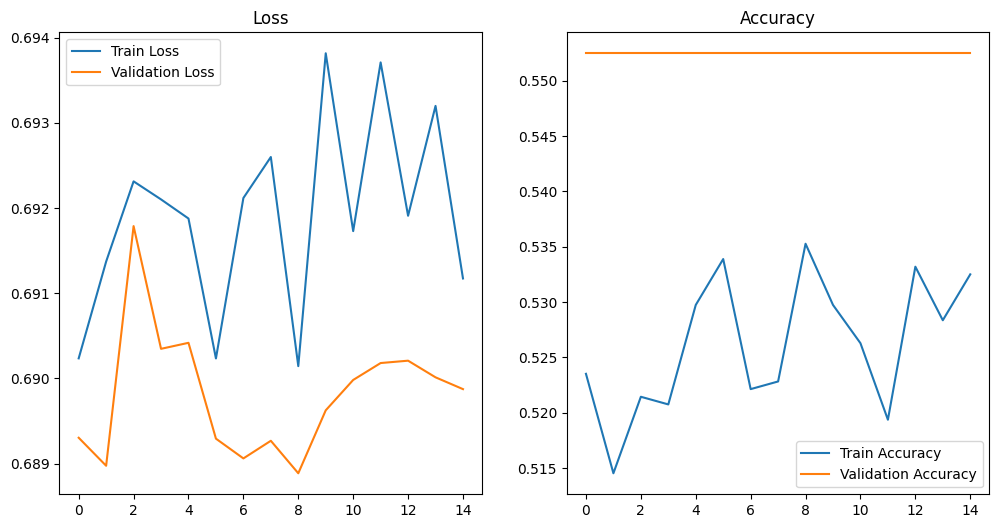

In [47]:
# Courbes de perte et d'exactitude
plt.figure(figsize=(12, 6))

# Perte
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

# Précision
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.show()

In [48]:
y_pred = (model.predict(x_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

12/12 [==============================] - 0s 530us/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       162
           1       0.55      1.00      0.71       200

    accuracy                           0.55       362
   macro avg       0.28      0.50      0.36       362
weighted avg       0.31      0.55      0.39       362



/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/thibaultjames/anaconda3/envs/ISLP/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, m

In [49]:
model = Sequential()

# Convolutional layer (1D)
model.add(Conv1D(64, 3, activation='relu', input_shape=(x_train.shape[1], 1)))  # Ajuste le input_shape
model.add(MaxPooling1D(2))

# Aplatir pour les couches denses
model.add(Flatten())

# Couches denses
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Dropout pour éviter le surapprentissage

# Sortie
model.add(Dense(1, activation='sigmoid'))  # Pour une classification binaire

# Compilation du modèle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Résumé du modèle
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 3, 64)             256       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 1, 64)            0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 128)               8320      
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                      

In [50]:
history = model.fit(x_train, y_train, epochs=15, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/15
46/46 [==============================] - 1s 3ms/step - loss: 0.6926 - accuracy: 0.5346 - val_loss: 0.6907 - val_accuracy: 0.5525
Epoch 2/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6920 - accuracy: 0.5477 - val_loss: 0.6906 - val_accuracy: 0.5525
Epoch 3/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6923 - accuracy: 0.5249 - val_loss: 0.6882 - val_accuracy: 0.5525
Epoch 4/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6921 - accuracy: 0.5284 - val_loss: 0.6898 - val_accuracy: 0.5525
Epoch 5/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6915 - accuracy: 0.5256 - val_loss: 0.6889 - val_accuracy: 0.5525
Epoch 6/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6922 - accuracy: 0.5311 - val_loss: 0.6888 - val_accuracy: 0.5525
Epoch 7/15
46/46 [==============================] - 0s 1ms/step - loss: 0.6920 - accuracy: 0.5207 - val_loss: 0.6901 - val_accuracy: 0.5525
Epoch 8/15
46/46 [==

In [51]:
# Fonction pour créer le modèle CNN
def create_model(input_shape):
    model = Sequential()
    model.add(Conv1D(64, 3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Pour une classification binaire
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Validation croisée avec KFold
def cross_validate_CNN(X, y, n_splits=5, epochs=10, batch_size=32):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_accuracies = []

    for train_index, val_index in kf.split(X):
        # Diviser les données en train et test
        x_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Réinitialiser le modèle pour chaque fold
        model = create_model((x_train.shape[1], 1))
        
        # Entraîner le modèle
        history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)

        # Évaluer le modèle
        val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
        fold_accuracies.append(val_accuracy)

        # Libérer la mémoire après chaque fold
        K.clear_session()

    # Calculer la moyenne des performances
    mean_accuracy = np.mean(fold_accuracies)
    return mean_accuracy

# Exemple d'utilisation
# Assurez-vous que X et y sont déjà définis, et X est sous forme de (samples, features)
mean_accuracy = cross_validate_CNN(x_train, y_train, n_splits=5, epochs=10, batch_size=32)
print(f"Accuracy moyenne sur les folds : {mean_accuracy:.4f}")


Accuracy moyenne sur les folds : 0.5325


Pour le moment l'accuracy est très mauvaise comme unu pile ou face afin d'augmenter la précision il faudrait pouvoir ajouter : 

1. Indicateurs Techniques
Moyennes Mobiles : Moyennes mobiles simples (SMA), exponentielles (EMA), etc.
RSI (Relative Strength Index) : Indicateur de momentum.
MACD (Moving Average Convergence Divergence) : Indicateur de tendance.
Bollinger Bands : Indicateur de volatilité.
Stochastic Oscillator : Indicateur de momentum.
2. Indicateurs de Volume
Volume de Transactions : Volume quotidien ou moyen sur une période.
On-Balance Volume (OBV) : Indicateur de momentum basé sur le volume.
3. Indicateurs de Volatilité
ATR (Average True Range) : Mesure de la volatilité.
Volatilité Historique : Calculée sur différentes périodes.
4. Indicateurs de Sentiment
Sentiment des Médias Sociaux : Analyse du sentiment des tweets ou des articles de presse.
Indicateurs de Positionnement : Comme le Commitment of Traders (COT) report.
5. Données Macroéconomiques
Taux d'Intérêt : Taux directeurs des banques centrales.
Indicateurs Économiques : PIB, taux de chômage, inflation, etc.
Indices de Marché : S&P 500, VIX (indice de volatilité), etc.
6. Données de Marché
Prix des Commodities : Or, pétrole, etc.
Taux de Change : Principales paires de devises.
7. Features Temporelles
Jour de la Semaine : Effet calendaire.
Mois de l'Année : Saisonnalité.
Heure de la Journée : Pour les données intraday.
8. Features Dérivées
Ratios Financiers : P/E ratio, ROE, etc.
Combinations de Greeks : Par exemple, le rapport Delta/Gamma.
9. Données Alternatives
Données de Satellite : Pour suivre l'activité économique.
Données de Transaction par Carte de Crédit : Pour suivre la consommation.